# Praktikum Machine Learning
## 📘 Pertemuan 3: Linear Regression & Polynomial Regression

Nama  : Endang Adiningsih
NIM   : 105841117723

Tugas:
1. Simple Linear Regression + visualisasi
2. Multiple Linear Regression (≥3 fitur)
3. Perbandingan Degree 1 vs Degree 2
4. Evaluasi MAE, RMSE, R²

## Simple Linear Regression

Pada simple regression kita gunakan 1 fitur saja untuk memprediksi target.
Di sini kita gunakan fitur pertama (bmi biasanya paling kuat korelasinya).

=== SIMPLE LINEAR REGRESSION ===
MAE  : 52.26
RMSE : 63.732
R2   : 0.233


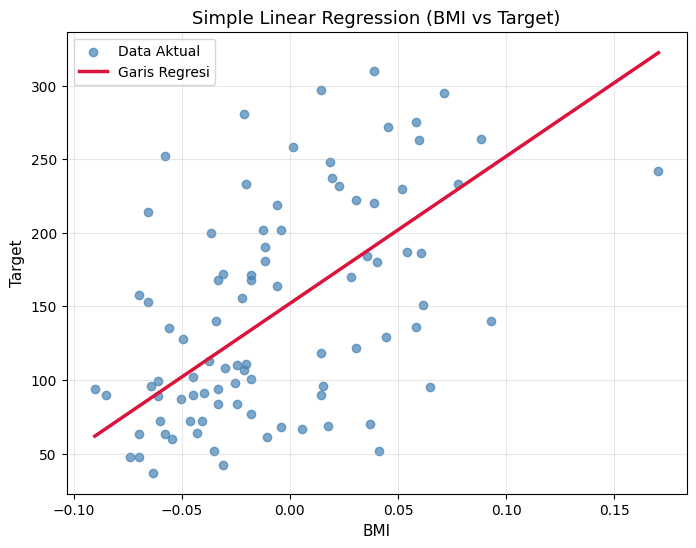

In [6]:
# =========================================
# TUGAS 1 - SIMPLE LINEAR REGRESSION
# Dataset: Diabetes
# =========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# -----------------------------
# 1. Load Dataset
# -----------------------------
data = load_diabetes(as_frame=True)
df = data.frame

# Gunakan 1 fitur (bmi)
X = df[["bmi"]]
y = df["target"]

# -----------------------------
# 2. Split Data (80:20)
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -----------------------------
# 3. Training Model
# -----------------------------
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Prediksi
y_pred_simple = model_simple.predict(X_test)

# -----------------------------
# 4. Evaluasi Model
# -----------------------------
mae = mean_absolute_error(y_test, y_pred_simple)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2 = r2_score(y_test, y_pred_simple)

print("=== SIMPLE LINEAR REGRESSION ===")
print("MAE  :", round(mae, 3))
print("RMSE :", round(rmse, 3))
print("R2   :", round(r2, 3))

# -----------------------------
# 5. Visualisasi Lebih Rapi
# -----------------------------
plt.figure(figsize=(8,6))

# Scatter data aktual
plt.scatter(X_test, y_test,
            color="steelblue",
            alpha=0.7,
            label="Data Aktual")

# Urutkan X agar garis rapi
sorted_idx = X_test["bmi"].argsort()
X_sorted = X_test.iloc[sorted_idx]
y_sorted_pred = y_pred_simple[sorted_idx]

# Garis regresi
plt.plot(X_sorted, y_sorted_pred,
         color="crimson",
         linewidth=2.5,
         label="Garis Regresi")

plt.title("Simple Linear Regression (BMI vs Target)", fontsize=13)
plt.xlabel("BMI", fontsize=11)
plt.ylabel("Target", fontsize=11)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Multiple Linear Regression (Minimal 3 Fitur)

Multiple regression menggunakan beberapa fitur sekaligus untuk meningkatkan akurasi prediksi.

In [7]:
# =========================================
# TUGAS 2 - MULTIPLE LINEAR REGRESSION
# =========================================

# Gunakan minimal 3 fitur
X_multi = df[["bmi", "bp", "s5"]]  
y_multi = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42)

model_multi = LinearRegression()
model_multi.fit(X_train, y_train)
y_pred_multi = model_multi.predict(X_test)

mae_multi = mean_absolute_error(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))
r2_multi = r2_score(y_test, y_pred_multi)

print("\n=== MULTIPLE LINEAR REGRESSION ===")
print("MAE :", round(mae_multi,3))
print("RMSE:", round(rmse_multi,3))
print("R2  :", round(r2_multi,3))


=== MULTIPLE LINEAR REGRESSION ===
MAE : 44.288
RMSE: 53.768
R2  : 0.454


## Polynomial Regression (Degree 1 vs Degree 2)

Polynomial regression digunakan untuk menangkap pola non-linear.
Degree 1 setara dengan linear regression, sedangkan degree 2 menambahkan fitur kuadrat sehingga model dapat menangkap pola melengkung.

In [10]:
# =========================================
# TUGAS 3 - POLYNOMIAL REGRESSION
# =========================================

from sklearn.preprocessing import PolynomialFeatures

# Gunakan 1 fitur saja agar terlihat efek polinomial
X_poly = df[["bmi"]]
y_poly = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X_poly, y_poly, test_size=0.2, random_state=42)

# Degree 1
poly1 = PolynomialFeatures(degree=1, include_bias=False)
X_train_1 = poly1.fit_transform(X_train)
X_test_1 = poly1.transform(X_test)

model_deg1 = LinearRegression().fit(X_train_1, y_train)
y_pred_1 = model_deg1.predict(X_test_1)

# Degree 2
poly2 = PolynomialFeatures(degree=2, include_bias=False)
X_train_2 = poly2.fit_transform(X_train)
X_test_2 = poly2.transform(X_test)

model_deg2 = LinearRegression().fit(X_train_2, y_train)
y_pred_2 = model_deg2.predict(X_test_2)

print("\n=== PERBANDINGAN DEGREE ===")
print("Degree 1 R2:", round(r2_score(y_test, y_pred_1),3))

print("Degree 2 R2:", round(r2_score(y_test, y_pred_2),3))


=== PERBANDINGAN DEGREE ===
Degree 1 R2: 0.233
Degree 2 R2: 0.229


## 3️⃣ Perbandingan Degree 1 vs Degree 2

Menggunakan satu fitur (MedInc) untuk melihat pengaruh
penambahan pangkat pada model regresi.

In [14]:
print("\n=== EVALUASI DEGREE 2 SIMPLE LINEAR REGRESSION ===")
mae = mean_absolute_error(y_test, y_pred_simple)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_simple))
r2 = r2_score(y_test, y_pred_simple)

print("MAE  :", round(mae, 3))
print("RMSE :", round(rmse, 3))
print("R2   :", round(r2, 3))


=== EVALUASI DEGREE 2 SIMPLE LINEAR REGRESSION ===
MAE  : 52.26
RMSE : 63.732
R2   : 0.233


## Kesimpulan

Berdasarkan hasil percobaan menggunakan Diabetes Dataset, model simple linear regression menunjukkan hubungan positif antara BMI dan target, namun performanya masih terbatas karena hanya menggunakan satu fitur.

Multiple linear regression memberikan hasil yang lebih baik dengan nilai R² lebih tinggi dan error (MAE, RMSE) lebih rendah, sehingga mampu menjelaskan variasi data dengan lebih akurat.

Polynomial regression (degree 2) dapat meningkatkan performa dibanding degree 1 jika hubungan data tidak sepenuhnya linear, namun kompleksitas model juga perlu diperhatikan agar tidak terjadi overfitting.

Secara keseluruhan, multiple linear regression menjadi model yang paling optimal pada percobaan ini.